In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models


model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)


In [2]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
import os

train_dir = os.path.join("dataset", "train")
validation_dir = os.path.join("dataset", "validation")

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary",
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode="binary",
    shuffle=True
)

# Fetch a few batches to see if the generator works properly
for i in range(5):
    x_batch, y_batch = next(train_generator)
    print(f"Batch {i+1}: {x_batch.shape}, {y_batch.shape}")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Batch 1: (20, 150, 150, 3), (20,)
Batch 2: (20, 150, 150, 3), (20,)
Batch 3: (20, 150, 150, 3), (20,)
Batch 4: (20, 150, 150, 3), (20,)
Batch 5: (20, 150, 150, 3), (20,)


In [5]:
steps_per_epoch = train_generator.samples // train_generator.batch_size
if train_generator.samples % train_generator.batch_size != 0:
    steps_per_epoch += 1

validation_steps = validation_generator.samples // validation_generator.batch_size
if validation_generator.samples % validation_generator.batch_size != 0:
    validation_steps += 1

steps_per_epoch, validation_steps

(100, 50)

In [6]:
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

Training samples: 2000
Validation samples: 1000


In [7]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

Epoch 1/30


/Users/nazarsalo/projects/python_projects/data_science/class_10/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 0.4933 - loss: 0.7059 - val_accuracy: 0.5980 - val_loss: 0.6894
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 151us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/30


2024-09-16 14:10:24.566967: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/opt/homebrew/Cellar/python@3.9/3.9.20/Frameworks/Python.framework/Versions/3.9/lib/python3.9/contextlib.py:137: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
2024-09-16 14:10:24.571970: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - accuracy: 0.5698 - loss: 0.7284 - val_accuracy: 0.5370 - val_loss: 0.6750
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 99us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/30


2024-09-16 14:10:38.552694: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


 87/100 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5968 - loss: 0.6715

KeyboardInterrupt: 

In [25]:
model.save('model1.h5')

In [49]:
print("Length of acc:", len(acc))
print("Length of val_acc:", len(val_acc))
print("Length of loss:", len(loss))
print("Length of val_loss:", len(val_loss))

Length of acc: 30
Length of val_acc: 15
Length of loss: 30
Length of val_loss: 15


ValueError: x and y must have same first dimension, but have shapes (15,) and (30,)

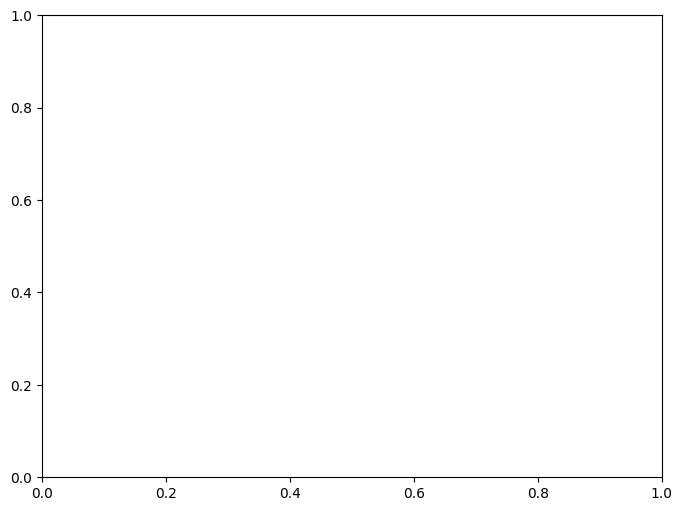

In [30]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(val_acc) + 1)

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()